# DPRNet-Bi: Physics-Informed Bidirectional LSTM
**Ventilator Pressure Prediction** — Google Brain Kaggle Dataset → MIMICS III Generalisation

**Instructions:**
1. Go to **Runtime → Change runtime type → T4 GPU** before running
2. Run cells sequentially (Ctrl+F9 = Run All, or Shift+Enter cell by cell)
3. In **Cell 2**, upload your `kaggle.json` when prompted
4. All outputs are saved to `/content/dprnet_bi_outputs/`
5. Run **Cell 16** at the end to download all results

## Cell 1: Install & imports

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "kaggle", "scipy", "scikit-learn",
                "matplotlib", "seaborn", "pandas", "numpy", "torch",
                "torchvision", "tqdm"], check=True)

import os, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image as IPImage
from pathlib import Path
from tqdm.auto import tqdm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ── reproducibility ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

OUTPUT_DIR = Path("/content/dprnet_bi_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs → {OUTPUT_DIR}")

Device: cuda
Outputs → /content/dprnet_bi_outputs


## Cell 2: Google Drive Data Mount


In [2]:
# ============================================================
# GOOGLE DRIVE DATA MOUNT
# ============================================================

from google.colab import drive
import os
from pathlib import Path
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# ============================================================
# UPDATE THIS PATH
# ============================================================

DATA_DIR = Path("/content/drive/MyDrive/Dataset")

# ============================================================
# CHECK FOLDER
# ============================================================

assert DATA_DIR.exists(), (
    f"❌ Folder not found: {DATA_DIR}\n"
    "→ Check your Google Drive path"
)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

assert TRAIN_PATH.exists(), (
    f"❌ train.csv not found in {DATA_DIR}"
)

assert TEST_PATH.exists(), (
    f"❌ test.csv not found in {DATA_DIR}"
)

print("✅ Drive mounted and dataset folder found")
print(f"DATA_DIR  : {DATA_DIR}")
print(f"train.csv : {TRAIN_PATH}")
print(f"test.csv  : {TEST_PATH}")

# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"\nTrain Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")

display(train_df.head())

Mounted at /content/drive
✅ Drive mounted and dataset folder found
DATA_DIR  : /content/drive/MyDrive/Dataset
train.csv : /content/drive/MyDrive/Dataset/train.csv
test.csv  : /content/drive/MyDrive/Dataset/test.csv

Train Shape : (6036000, 8)
Test Shape  : (4024000, 7)


,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


## Cell 3: Hyperparameters & config

In [3]:
CFG = {
    # data
    "window_size":    80,       # each breath = 80 timesteps
    "val_fraction":   0.15,
    "test_fraction":  0.10,
    "roll_window":    10,       # rolling stats window

    # model
    "hidden_size":    256,
    "num_layers":     3,
    "dropout":        0.2,

    # training
    "batch_size":     512,
    "lr":             1e-3,
    "weight_decay":   1e-5,
    "epochs":         80,
    "patience":       10,       # early stopping
    "grad_clip":      1.0,

    # physics init
    "alpha_init":     0.05,
    "tau_init":       0.05,
    "alpha_min":      0.0,      # physics parameter constraints
    "alpha_max":      2.0,
    "tau_min":        0.0,
    "tau_max":        2.0,
    "physics_weight": 0.1,      # auxiliary physics consistency loss
}

FEATURE_COLS = [
    "u_in_norm", "R_norm", "t_norm", "C_norm",
    "u_in_roll_max", "u_in_lag1", "u_out_norm",
    "u_in_roll_mean", "u_in_diff", "u_in_cumsum"
]
INPUT_SIZE = len(FEATURE_COLS)
print(f"Input features ({INPUT_SIZE}): {FEATURE_COLS}")

Input features (10): ['u_in_norm', 'R_norm', 't_norm', 'C_norm', 'u_in_roll_max', 'u_in_lag1', 'u_out_norm', 'u_in_roll_mean', 'u_in_diff', 'u_in_cumsum']


## Cell 4: Load & engineer features

In [4]:
def engineer_features(df: pd.DataFrame, scaler: StandardScaler = None,
                       fit_scaler: bool = False) -> tuple:
    """
    Engineers all 10 features consistent with prior experiments.
    Returns (feature_array, target_array, breath_ids, scaler).
    """
    df = df.sort_values(["breath_id", "time_step"]).copy()

    # ── per-breath rolling / lag features ──
    grp = df.groupby("breath_id")

    df["u_in_roll_mean"] = grp["u_in"].transform(
        lambda x: x.rolling(CFG["roll_window"], min_periods=1).mean())
    df["u_in_roll_max"]  = grp["u_in"].transform(
        lambda x: x.rolling(CFG["roll_window"], min_periods=1).max())
    df["u_in_lag1"]      = grp["u_in"].transform(lambda x: x.shift(1).fillna(0))
    df["u_in_diff"]      = grp["u_in"].transform(lambda x: x.diff().fillna(0))
    df["u_in_cumsum"]    = grp["u_in"].transform("cumsum")

    # ── raw features ──
    raw_cols = ["u_in", "R", "time_step", "C", "u_out",
                "u_in_roll_mean", "u_in_roll_max",
                "u_in_lag1", "u_in_diff", "u_in_cumsum"]

    if fit_scaler:
        scaler = StandardScaler()
        df[raw_cols] = scaler.fit_transform(df[raw_cols])
    else:
        df[raw_cols] = scaler.transform(df[raw_cols])

    # rename to match FEATURE_COLS
    df.rename(columns={
        "u_in":        "u_in_norm",
        "R":           "R_norm",
        "time_step":   "t_norm",
        "C":           "C_norm",
        "u_out":       "u_out_norm",
    }, inplace=True)

    # ── group into windows of shape (B, 80, 10) ──
    breath_ids = df["breath_id"].unique()
    X_list, y_list, bid_list = [], [], []

    for bid in tqdm(breath_ids, desc="Building windows", leave=False):
        b = df[df["breath_id"] == bid]
        if len(b) != CFG["window_size"]:
            continue
        X_list.append(b[FEATURE_COLS].values.astype(np.float32))
        if "pressure" in df.columns:
            y_list.append(b["pressure"].values.astype(np.float32))
        bid_list.append(bid)

    X = np.stack(X_list)                          # (N, 80, 10)
    y = np.stack(y_list) if y_list else None       # (N, 80)
    return X, y, np.array(bid_list), scaler


print("Loading train.csv …")
train_raw = pd.read_csv(DATA_DIR / "train.csv")
print(f"  Rows: {len(train_raw):,}  |  Breaths: {train_raw['breath_id'].nunique():,}")

# ── train / val / test split by breath_id ──
breath_ids = train_raw["breath_id"].unique()
np.random.shuffle(breath_ids)

n_val  = int(len(breath_ids) * CFG["val_fraction"])
n_test = int(len(breath_ids) * CFG["test_fraction"])
val_ids  = breath_ids[:n_val]
test_ids = breath_ids[n_val:n_val + n_test]
train_ids = breath_ids[n_val + n_test:]

train_df = train_raw[train_raw["breath_id"].isin(train_ids)]
val_df   = train_raw[train_raw["breath_id"].isin(val_ids)]
test_df  = train_raw[train_raw["breath_id"].isin(test_ids)]

print(f"  Train breaths: {len(train_ids):,} | Val: {len(val_ids):,} | Test: {len(test_ids):,}")

print("Engineering features …")
X_train, y_train, bid_train, scaler = engineer_features(train_df, fit_scaler=True)
X_val,   y_val,   bid_val,   _      = engineer_features(val_df,   scaler=scaler)
X_test,  y_test,  bid_test,  _      = engineer_features(test_df,  scaler=scaler)

# ── save scaler ──
import pickle
with open(OUTPUT_DIR / "feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# ── pressure scaler (target) ──
p_mean = train_df["pressure"].mean()
p_std  = train_df["pressure"].std()
y_train = (y_train - p_mean) / p_std
y_val   = (y_val   - p_mean) / p_std
y_test  = (y_test  - p_mean) / p_std

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loading train.csv …
  Rows: 6,036,000  |  Breaths: 75,450
  Train breaths: 56,588 | Val: 11,317 | Test: 7,545
Engineering features …


Building windows:   0%|          | 0/56588 [00:00<?, ?it/s]

Building windows:   0%|          | 0/11317 [00:00<?, ?it/s]

Building windows:   0%|          | 0/7545 [00:00<?, ?it/s]

X_train: (56588, 80, 10)  y_train: (56588, 80)
X_val:   (11317, 80, 10)    y_val:   (11317, 80)
X_test:  (7545, 80, 10)   y_test:  (7545, 80)


## Cell 5: PyTorch Dataset

In [5]:
class VentilatorDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)    # (N, 80, 10)
        self.y = torch.from_numpy(y)    # (N, 80)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te):
    # num_workers=2 with persistent_workers avoids Colab multiprocessing hangs;
    # if you see DataLoader errors, set num_workers=0 as a fallback.
    nw = 2
    kw = dict(num_workers=nw, pin_memory=True, persistent_workers=(nw > 0))
    tr = DataLoader(VentilatorDataset(X_tr, y_tr),
                    batch_size=CFG["batch_size"], shuffle=True, **kw)
    v  = DataLoader(VentilatorDataset(X_v,  y_v),
                    batch_size=CFG["batch_size"] * 2, shuffle=False, **kw)
    te = DataLoader(VentilatorDataset(X_te, y_te),
                    batch_size=CFG["batch_size"] * 2, shuffle=False, **kw)
    return tr, v, te

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test)
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# ── feature index helpers (for physics branch) ──
FEAT_IDX = {f: i for i, f in enumerate(FEATURE_COLS)}
IDX_U_IN     = FEAT_IDX["u_in_norm"]
IDX_U_CUMSUM = FEAT_IDX["u_in_cumsum"]

Train batches: 111 | Val: 12 | Test: 8


## Cell 6: DPRNet-Bi model

In [6]:
class DPRNetBi(nn.Module):
    """
    Physics-Decomposed Residual Network with Bidirectional LSTM.

    Architecture
    ────────────
    Input x  →  [Physics branch]   α · cumsum(u_in) + τ · u_in
                 [BiLSTM branch]   BiLSTM(x) → FC → residual
                 [Sum]             physics + residual = ŷ

    The physics branch is a learnable first-order lung model.
    The BiLSTM residual corrects for active patient effort (Pmus)
    and mode-specific deviations using within-breath future context.
    Both α and τ are constrained to [0, 2] via sigmoid re-parameterisation
    to keep the physics prior interpretable.
    """

    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int, dropout: float,
                 alpha_init: float = 0.05, tau_init: float = 0.05):
        super().__init__()

        # ── constrained physics parameters ──
        # stored in unconstrained logit space; mapped via sigmoid × max
        self._alpha_raw = nn.Parameter(
            torch.tensor(self._to_logit(alpha_init,
                                        CFG["alpha_min"], CFG["alpha_max"])))
        self._tau_raw   = nn.Parameter(
            torch.tensor(self._to_logit(tau_init,
                                        CFG["tau_min"], CFG["tau_max"])))

        # ── bidirectional LSTM residual branch ──
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # ── layer norm for stability ──
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # ── output projection ──
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size, 1)
        )

    # ── physics parameter accessors ──
    @staticmethod
    def _to_logit(val, lo, hi):
        val = max(lo + 1e-6, min(hi - 1e-6, val))
        p = (val - lo) / (hi - lo)
        return math.log(p / (1 - p))

    @property
    def alpha(self):
        return (CFG["alpha_max"] - CFG["alpha_min"]) * \
               torch.sigmoid(self._alpha_raw) + CFG["alpha_min"]

    @property
    def tau(self):
        return (CFG["tau_max"] - CFG["tau_min"]) * \
               torch.sigmoid(self._tau_raw) + CFG["tau_min"]

    def physics_branch(self, x: torch.Tensor) -> torch.Tensor:
        """
        Computes α · cumsum(u_in_norm) + τ · u_in_norm
        x: (B, T, F)
        returns: (B, T)
        """
        u_in     = x[:, :, IDX_U_IN]       # (B, T)
        u_cumsum = x[:, :, IDX_U_CUMSUM]   # (B, T)
        return self.alpha * u_cumsum + self.tau * u_in

    def forward(self, x: torch.Tensor):
        """
        x: (B, T, F)
        returns: prediction (B,T), physics (B,T), residual (B,T)
        """
        # physics prior
        physics = self.physics_branch(x)             # (B, T)

        # BiLSTM residual
        lstm_out, _ = self.bilstm(x)                 # (B, T, 2H)
        lstm_out = self.layer_norm(lstm_out)
        lstm_out = self.dropout(lstm_out)
        residual = self.fc(lstm_out).squeeze(-1)     # (B, T)

        prediction = physics + residual
        return prediction, physics, residual


model = DPRNetBi(
    input_size=INPUT_SIZE,
    hidden_size=CFG["hidden_size"],
    num_layers=CFG["num_layers"],
    dropout=CFG["dropout"],
    alpha_init=CFG["alpha_init"],
    tau_init=CFG["tau_init"]
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DPRNet-Bi  |  Parameters: {total_params:,}")
print(f"  Initial α = {model.alpha.item():.4f}  |  τ = {model.tau.item():.4f}")

DPRNet-Bi  |  Parameters: 3,835,395
  Initial α = 0.0500  |  τ = 0.0500


## Cell 7: Loss functions

In [7]:
class DPRNetBiLoss(nn.Module):
    """
    Combined loss:
        L = MAE(prediction, target)
          + physics_weight × MAE(physics, target)   [physics consistency]

    The auxiliary physics term discourages the physics branch from
    collapsing to zero (a failure mode seen in DPRNet v4/v5).
    """
    def __init__(self, physics_weight: float = 0.1):
        super().__init__()
        self.w = physics_weight
        self.mae = nn.L1Loss()

    def forward(self, pred, physics, target):
        main_loss    = self.mae(pred, target)
        physics_loss = self.mae(physics, target)
        return main_loss + self.w * physics_loss, main_loss, physics_loss


criterion = DPRNetBiLoss(physics_weight=CFG["physics_weight"])
print("Loss: MAE + physics consistency auxiliary")

Loss: MAE + physics consistency auxiliary


## Cell 8: Training


Training for up to 80 epochs  (patience=10)

Epoch      Train        Val        α        τ     Phys_L
──────────────────────────────────────────────────────────
    1     0.1296     0.1162   0.0495   0.0510     0.7484
    5     0.1056     0.1057   0.0495   0.0557     0.7472
   10     0.0868     0.0807   0.0495   0.0714     0.7428
   15     0.0642     0.0598   0.0493   0.0963     0.7358
   20     0.0575     0.0471   0.0489   0.1262     0.7278
   25     0.0520     0.0459   0.0485   0.1594     0.7197
   30     0.0494     0.0418   0.0478   0.1904     0.7128
   35     0.0466     0.0407   0.0469   0.2173     0.7075
   40     0.0441     0.0362   0.0459   0.2403     0.7034
   45     0.0428     0.0358   0.0449   0.2596     0.7003
   50     0.0408     0.0337   0.0441   0.2750     0.6979
   55     0.0397     0.0323   0.0434   0.2871     0.6962
   60     0.0388     0.0333   0.0428   0.2958     0.6950
   65     0.0381     0.0310   0.0425   0.3015     0.6942
   70     0.0373     0.0304   0.0423   0

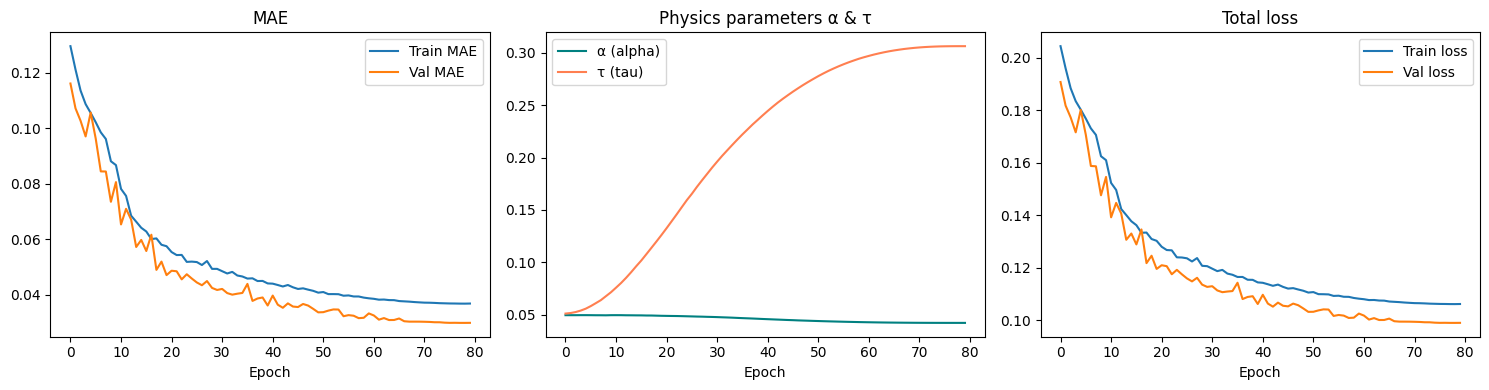

Training curves saved.


In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG["lr"],
    epochs=CFG["epochs"],
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy="cos"
)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, main_t, phys_t, n = 0.0, 0.0, 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred, physics, residual = model(X)
            loss, main_l, phys_l = criterion(pred, physics, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                optimizer.step()
                scheduler.step()
            total  += loss.item()    * len(X)
            main_t += main_l.item()  * len(X)
            phys_t += phys_l.item()  * len(X)
            n += len(X)
    return total / n, main_t / n, phys_t / n


history = {"train_loss": [], "val_loss": [],
           "train_mae": [], "val_mae": [],
           "alpha": [], "tau": []}

best_val, patience_counter = float("inf"), 0
best_ckpt = OUTPUT_DIR / "dprnet_bi_best.pt"

print(f"\nTraining for up to {CFG['epochs']} epochs  (patience={CFG['patience']})\n")
print(f"{'Epoch':>5} {'Train':>10} {'Val':>10} {'α':>8} {'τ':>8} {'Phys_L':>10}")
print("─" * 58)

for epoch in range(1, CFG["epochs"] + 1):
    tr_loss, tr_mae, tr_phy = run_epoch(train_loader, train=True)
    vl_loss, vl_mae, vl_phy = run_epoch(val_loader,   train=False)

    a = model.alpha.item()
    t = model.tau.item()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_mae"].append(tr_mae)
    history["val_mae"].append(vl_mae)
    history["alpha"].append(a)
    history["tau"].append(t)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5} {tr_mae:>10.4f} {vl_mae:>10.4f} "
              f"{a:>8.4f} {t:>8.4f} {tr_phy:>10.4f}")

    if vl_loss < best_val:
        best_val = vl_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": best_val,
            "alpha": a, "tau": t,
            "cfg": CFG
        }, best_ckpt)
    else:
        patience_counter += 1
        if patience_counter >= CFG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}  "
                  f"(best val MAE = {best_val:.4f})")
            break

print(f"\nBest checkpoint saved → {best_ckpt}")

# ── training curves ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_mae"], label="Train MAE")
axes[0].plot(history["val_mae"],   label="Val MAE")
axes[0].set_title("MAE"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["alpha"], color="teal", label="α (alpha)")
axes[1].plot(history["tau"],   color="coral", label="τ (tau)")
axes[1].set_title("Physics parameters α & τ")
axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history["train_loss"], label="Train loss")
axes[2].plot(history["val_loss"],   label="Val loss")
axes[2].set_title("Total loss"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "DPRNet_Bi_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Training curves saved.")

## Cell 9: Evaluation metrics

In [11]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Computes the full metric suite matching all prior experiments.
    Inputs are flat 1-D arrays (all timesteps concatenated).
    """
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2   = 1 - ss_res / ss_tot

    diff = y_true - y_pred
    bias = np.mean(diff)
    loa  = 1.96 * np.std(diff)

    within1 = np.mean(np.abs(diff) <= 1.0) * 100
    within2 = np.mean(np.abs(diff) <= 2.0) * 100

    # PEVR — proportion of error variance relative to total
    pevr = 1 - np.var(diff) / np.var(y_true)

    # RMR — relative mean residual
    rmr = mae / (np.mean(np.abs(y_true)) + 1e-8)

    # alpha — concordance correlation coefficient
    mu_t, mu_p = np.mean(y_true), np.mean(y_pred)
    s_t, s_p   = np.std(y_true), np.std(y_pred)
    cov        = np.mean((y_true - mu_t) * (y_pred - mu_p))
    alpha_ccc  = 2 * cov / (s_t**2 + s_p**2 + (mu_t - mu_p)**2 + 1e-8)

    # tau — Kendall rank correlation (sampled for speed)
    n_sample = min(50000, len(y_true))
    idx = np.random.choice(len(y_true), n_sample, replace=False)
    tau, _ = stats.kendalltau(y_true[idx], y_pred[idx])

    return {
        "MAE": float(mae), "RMSE": float(rmse), "R2": float(r2),
        "Bias": float(bias), "LoA": float(loa),
        "Within1": float(within1), "Within2": float(within2),
        "PEVR": float(pevr), "RMR": float(rmr),
        "alpha": float(alpha_ccc), "tau": float(tau)
    }


def get_predictions(loader):
    """Returns (y_true, y_pred, physics, residual) as flat numpy arrays."""
    ckpt = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    yt_list, yp_list, ph_list, res_list = [], [], [], []
    with torch.no_grad():
        for X, y in tqdm(loader, desc="Predicting", leave=False):
            X = X.to(DEVICE)
            pred, physics, residual = model(X)
            yt_list.append(y.numpy())
            yp_list.append(pred.cpu().numpy())
            ph_list.append(physics.cpu().numpy())
            res_list.append(residual.cpu().numpy())

    return (np.concatenate(yt_list).ravel(),
            np.concatenate(yp_list).ravel(),
            np.concatenate(ph_list).ravel(),
            np.concatenate(res_list).ravel())


print("Running test-set inference …")
y_true, y_pred, y_physics, y_residual = get_predictions(test_loader)

metrics = compute_metrics(y_true, y_pred)
metrics_path = OUTPUT_DIR / "DPRNet_Bi_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n── DPRNet-Bi Test Metrics ──")
for k, v in metrics.items():
    print(f"  {k:>10}: {v:.6f}")

Running test-set inference …


Predicting:   0%|          | 0/8 [00:00<?, ?it/s]


── DPRNet-Bi Test Metrics ──
         MAE: 0.030053
        RMSE: 0.049244
          R2: 0.997571
        Bias: -0.000087
         LoA: 0.096518
     Within1: 100.000000
     Within2: 100.000000
        PEVR: 0.997571
         RMR: 0.039342
       alpha: 0.998791
         tau: 0.914429


## Cell 10: Evaluation plots (eval triptych)

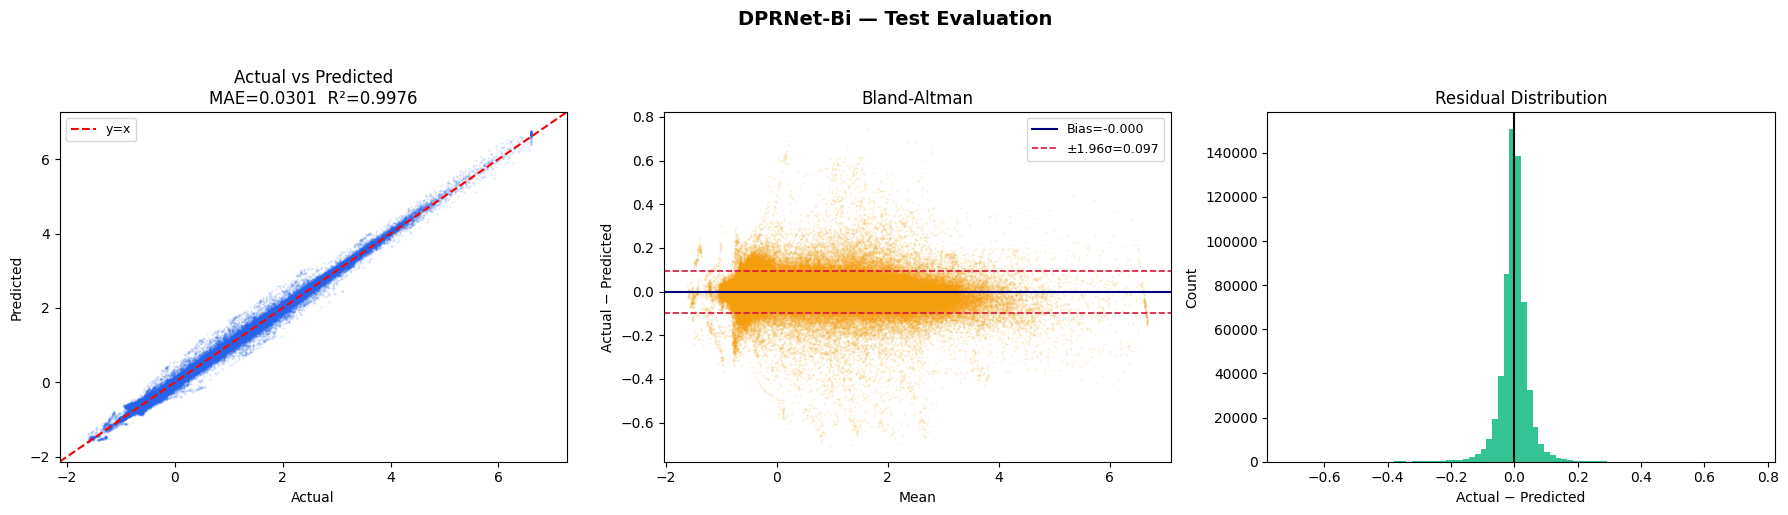

  Saved → DPRNet_Bi_eval.png


In [12]:
def plot_eval(y_true, y_pred, title, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    # ── Actual vs Predicted ──
    ax = axes[0]
    ax.scatter(y_true, y_pred, s=0.3, alpha=0.15, color="#2563EB", rasterized=True)
    lim = [min(y_true.min(), y_pred.min()) - 0.5,
           max(y_true.max(), y_pred.max()) + 0.5]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="y=x")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    mae  = metrics["MAE"]; r2 = metrics["R2"]
    ax.set_title(f"Actual vs Predicted\nMAE={mae:.4f}  R²={r2:.4f}")
    ax.legend(fontsize=9)

    # ── Bland-Altman ──
    ax = axes[1]
    mean_vals = (y_true + y_pred) / 2
    diff_vals = y_true - y_pred
    bias = metrics["Bias"]; loa = metrics["LoA"]
    ax.scatter(mean_vals, diff_vals, s=0.3, alpha=0.15,
               color="#F59E0B", rasterized=True)
    ax.axhline(bias,       color="navy",    linewidth=1.5,
               label=f"Bias={bias:.3f}")
    ax.axhline(bias + loa, color="crimson", linewidth=1.2,
               linestyle="--", label=f"±1.96σ={loa:.3f}")
    ax.axhline(bias - loa, color="crimson", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Mean"); ax.set_ylabel("Actual − Predicted")
    ax.set_title("Bland-Altman")
    ax.legend(fontsize=9)

    # ── Residual distribution ──
    ax = axes[2]
    ax.hist(diff_vals, bins=80, color="#10B981", edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1.5)
    ax.set_xlabel("Actual − Predicted"); ax.set_ylabel("Count")
    ax.set_title("Residual Distribution")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {save_path.name}")


plot_eval(y_true, y_pred,
          title="DPRNet-Bi — Test Evaluation",
          save_path=OUTPUT_DIR / "DPRNet_Bi_eval.png")

## Cell 11: Physics vs residual decomposition (3 windows)

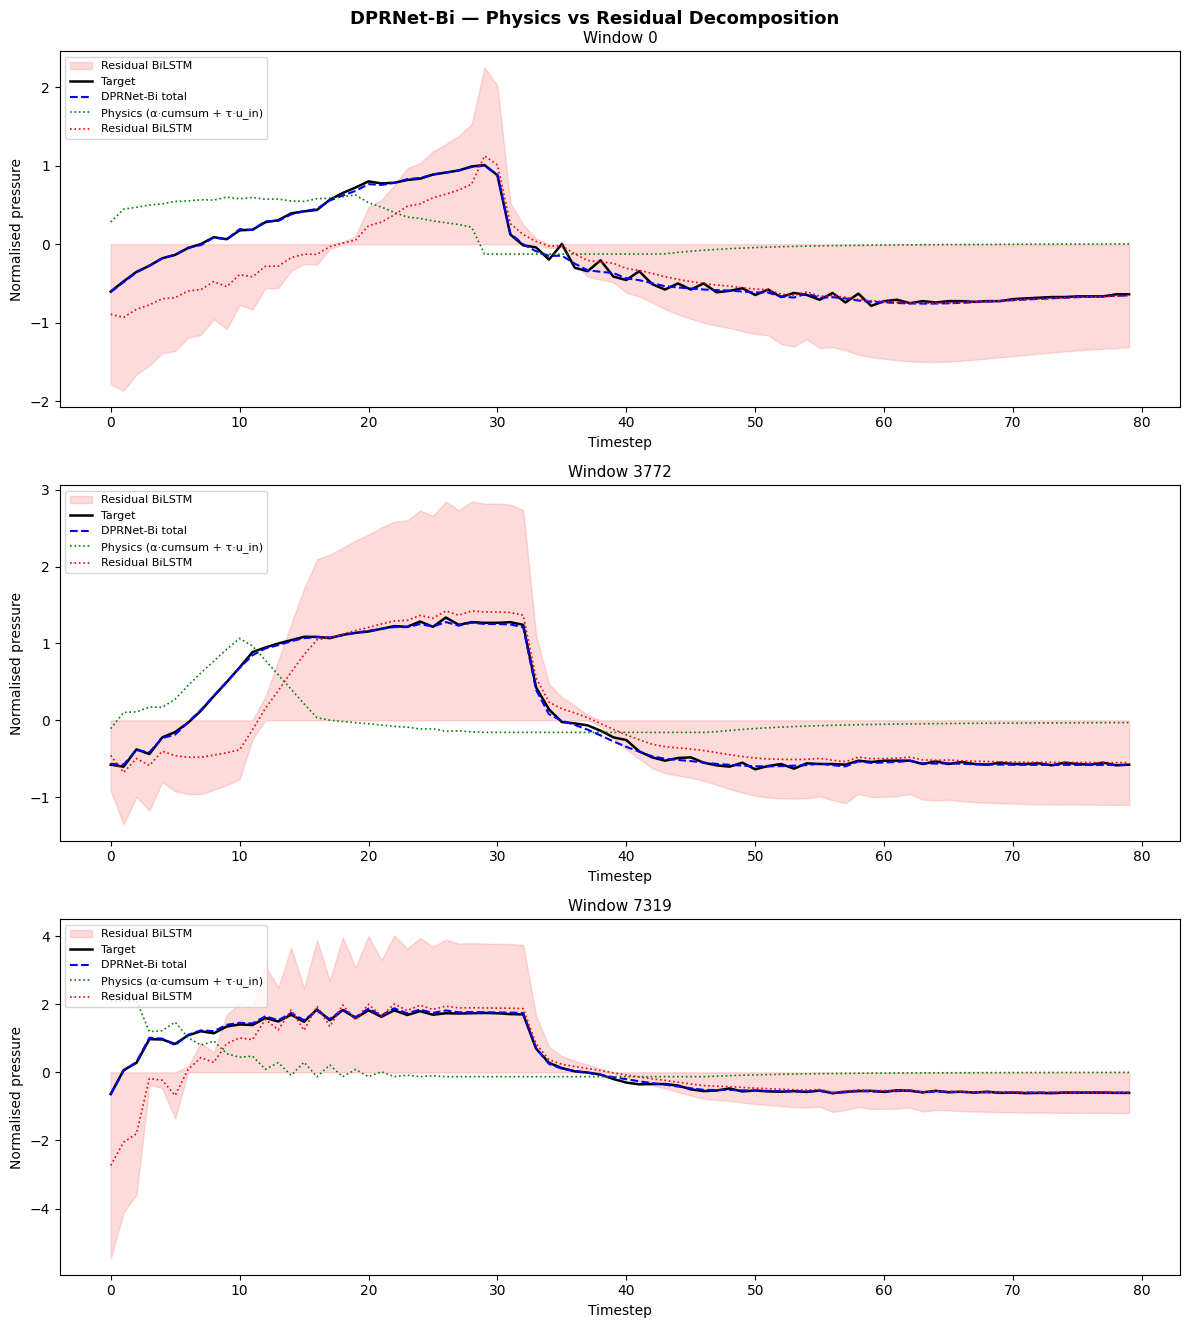

  Saved → DPRNet_Bi_decomposition.png


In [13]:
def plot_decomposition(X_data, y_data, window_indices, save_path):
    """
    Plots physics branch vs BiLSTM residual for specified windows.
    window_indices: list of integer indices into the test set.
    """
    model.eval()
    fig, axes = plt.subplots(len(window_indices), 1,
                              figsize=(12, 4.5 * len(window_indices)))
    fig.suptitle("DPRNet-Bi — Physics vs Residual Decomposition",
                 fontsize=13, fontweight="bold")

    with torch.no_grad():
        for ax, idx in zip(axes, window_indices):
            x_t = torch.from_numpy(X_data[idx:idx+1]).to(DEVICE)
            pred, physics, residual = model(x_t)

            t = np.arange(CFG["window_size"])
            target   = y_data[idx]
            p_np     = pred.cpu().numpy()[0]
            ph_np    = physics.cpu().numpy()[0]
            res_np   = residual.cpu().numpy()[0]
            res_std  = np.abs(res_np)

            ax.fill_between(t, res_np - res_std, res_np + res_std,
                            alpha=0.25, color="#F87171", label="Residual BiLSTM")
            ax.plot(t, target, "k-",    linewidth=1.8, label="Target")
            ax.plot(t, p_np,   "b--",   linewidth=1.5, label="DPRNet-Bi total")
            ax.plot(t, ph_np,  "g:",    linewidth=1.2,
                    label=f"Physics (α·cumsum + τ·u_in)")
            ax.plot(t, res_np, "r:",    linewidth=1.2, label="Residual BiLSTM")

            ax.set_title(f"Window {idx}", fontsize=11)
            ax.set_xlabel("Timestep"); ax.set_ylabel("Normalised pressure")
            ax.legend(fontsize=8, loc="upper left")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {save_path.name}")


# select representative windows (start, middle, late)
n_test_windows = len(X_test)
window_indices = [0,
                  n_test_windows // 2,
                  n_test_windows - int(n_test_windows * 0.03)]

plot_decomposition(X_test, y_test, window_indices,
                   OUTPUT_DIR / "DPRNet_Bi_decomposition.png")

## Cell 12: Feature importance via gradient × input

In [20]:
def compute_feature_importance(loader, n_batches=20):

    """
    Gradient × Input Feature Importance
    """

    # =========================================================
    # IMPORTANT FIX FOR GRU/LSTM + CUDA
    # =========================================================

    model.train()

    # Disable dropout randomness
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = 0.0

    grads_acc = np.zeros(INPUT_SIZE)
    count = 0

    # =========================================================
    # TEMPORARILY DISABLE CUDNN
    # =========================================================

    torch.backends.cudnn.enabled = False

    for i, (X, y) in enumerate(
        tqdm(loader,
             desc="Computing saliency",
             total=n_batches,
             leave=False)
    ):

        if i >= n_batches:
            break

        X = X.to(DEVICE)
        y = y.to(DEVICE)

        X.requires_grad_(True)

        # Clear gradients
        model.zero_grad()

        # Forward
        pred, physics, residual = model(X)

        # Loss
        loss = nn.L1Loss()(pred, y)

        # Backward
        loss.backward()

        # Gradient × Input
        gi = (
            X.grad.detach().abs()
            * X.detach().abs()
        )

        grads_acc += (
            gi.mean(dim=(0, 1))
            .cpu()
            .numpy()
        )

        count += 1

    # Re-enable cudnn
    torch.backends.cudnn.enabled = True

    if count == 0:
        raise ValueError("No batches processed")

    importance = grads_acc / count

    fi_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "Importance": importance
    })

    fi_df = (
        fi_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return fi_df

In [21]:
print("Computing feature importance …")

fi_df = compute_feature_importance(
    train_loader,
    n_batches=30
)

fi_df.to_csv(
    OUTPUT_DIR / "DPRNet_Bi_feature_importance.csv",
    index=False
)

print(fi_df)

Computing feature importance …


Computing saliency:   0%|          | 0/30 [00:00<?, ?it/s]

          Feature    Importance
0       u_in_norm  4.231856e-06
1      u_out_norm  2.409176e-06
2     u_in_cumsum  2.399111e-06
3       u_in_diff  2.268706e-06
4       u_in_lag1  2.207606e-06
5          t_norm  1.934718e-06
6          C_norm  1.619468e-06
7          R_norm  1.476355e-06
8  u_in_roll_mean  1.154430e-06
9   u_in_roll_max  7.163208e-07


## Cell 13: Intra-breath error profile

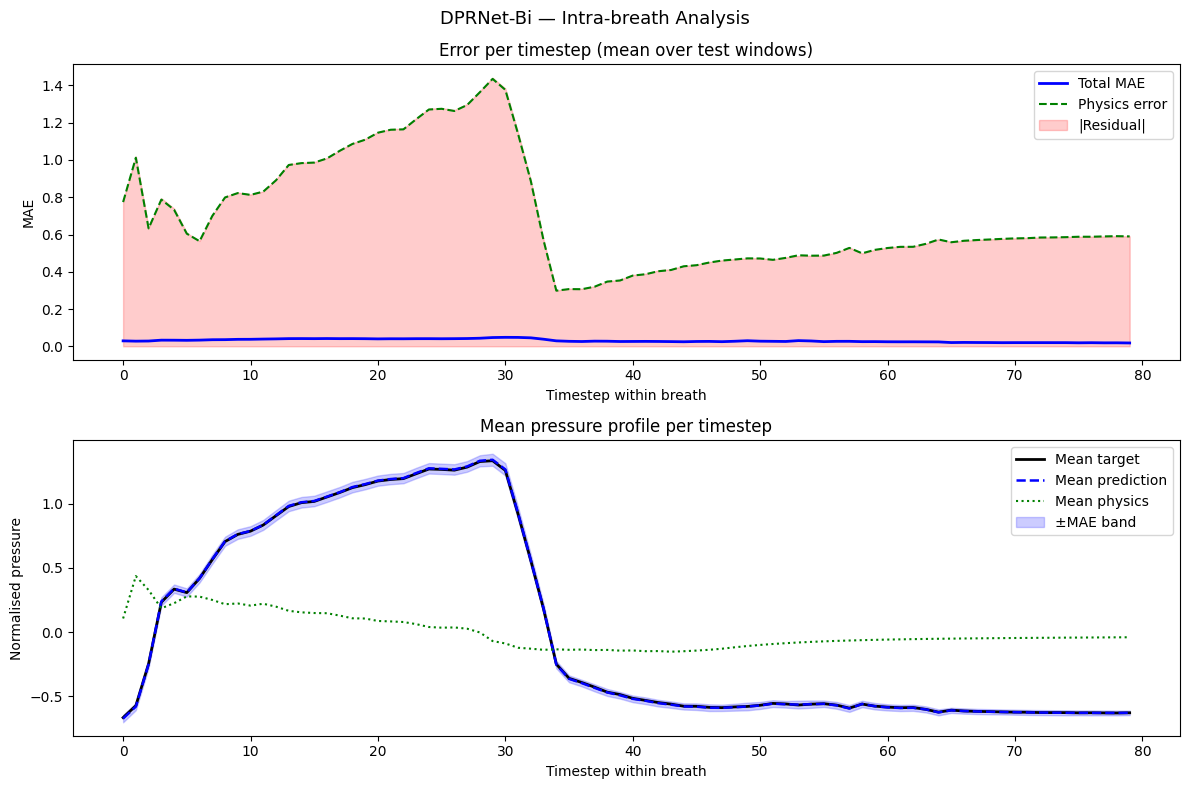

  Saved → DPRNet_Bi_intra_breath.png


In [22]:
def plot_intra_breath(X_data, y_data, save_path, n_sample=2000):
    """
    Shows mean absolute error at each timestep within a breath.
    Reveals whether error concentrates at inspiration onset,
    peak, or expiration — clinically interpretable.
    """
    model.eval()
    idx = np.random.choice(len(X_data), min(n_sample, len(X_data)), replace=False)
    X_s = torch.from_numpy(X_data[idx]).to(DEVICE)
    y_s = y_data[idx]

    with torch.no_grad():
        pred, physics, residual = model(X_s)

    pred_np    = pred.cpu().numpy()        # (N, 80)
    physics_np = physics.cpu().numpy()
    residual_np= residual.cpu().numpy()

    mae_per_step  = np.mean(np.abs(y_s - pred_np),    axis=0)
    phy_per_step  = np.mean(np.abs(y_s - physics_np), axis=0)
    res_magnitude = np.mean(np.abs(residual_np),       axis=0)

    t = np.arange(CFG["window_size"])
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle("DPRNet-Bi — Intra-breath Analysis", fontsize=13)

    # mean error per timestep
    ax = axes[0]
    ax.plot(t, mae_per_step,  "b-",  linewidth=2, label="Total MAE")
    ax.plot(t, phy_per_step,  "g--", linewidth=1.5, label="Physics error")
    ax.fill_between(t, 0, res_magnitude, alpha=0.2,
                    color="red", label="|Residual|")
    ax.set_xlabel("Timestep within breath"); ax.set_ylabel("MAE")
    ax.set_title("Error per timestep (mean over test windows)")
    ax.legend()

    # mean predictions vs target per timestep
    ax = axes[1]
    mean_target = np.mean(y_s, axis=0)
    mean_pred   = np.mean(pred_np, axis=0)
    mean_phys   = np.mean(physics_np, axis=0)
    ax.plot(t, mean_target, "k-",  linewidth=2,   label="Mean target")
    ax.plot(t, mean_pred,   "b--", linewidth=1.8, label="Mean prediction")
    ax.plot(t, mean_phys,   "g:",  linewidth=1.5, label="Mean physics")
    ax.fill_between(t, mean_pred - mae_per_step,
                       mean_pred + mae_per_step,
                    alpha=0.2, color="blue", label="±MAE band")
    ax.set_xlabel("Timestep within breath")
    ax.set_ylabel("Normalised pressure")
    ax.set_title("Mean pressure profile per timestep")
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {save_path.name}")


plot_intra_breath(X_test, y_test,
                  OUTPUT_DIR / "DPRNet_Bi_intra_breath.png")

## Cell 14: Physics parameter analysis

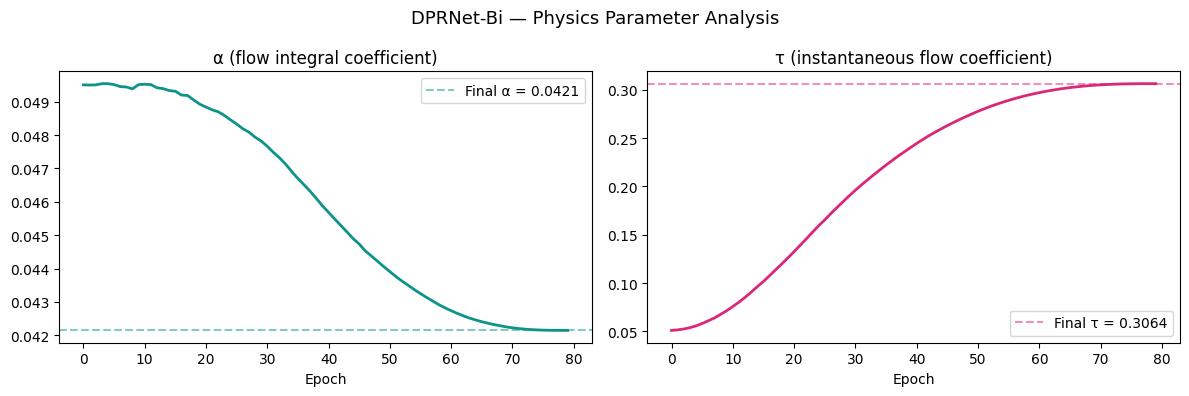


Final physics parameters:
  α (alpha) = 0.042149
  τ (tau)   = 0.306370

Variance decomposition (test set):
  Physics  contribution: 9.6%
  Residual contribution: 90.4%


In [23]:
ckpt = torch.load(best_ckpt, map_location=DEVICE)
final_alpha = ckpt["alpha"]
final_tau   = ckpt["tau"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("DPRNet-Bi — Physics Parameter Analysis", fontsize=13)

axes[0].plot(history["alpha"], color="#0D9488", linewidth=2)
axes[0].axhline(final_alpha, color="#0D9488", linestyle="--", alpha=0.5,
                label=f"Final α = {final_alpha:.4f}")
axes[0].set_title("α (flow integral coefficient)"); axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["tau"], color="#DB2777", linewidth=2)
axes[1].axhline(final_tau, color="#DB2777", linestyle="--", alpha=0.5,
                label=f"Final τ = {final_tau:.4f}")
axes[1].set_title("τ (instantaneous flow coefficient)"); axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "DPRNet_Bi_physics_params.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nFinal physics parameters:")
print(f"  α (alpha) = {final_alpha:.6f}")
print(f"  τ (tau)   = {final_tau:.6f}")

# ── physics contribution fraction ──
ph_var   = np.var(y_physics)
res_var  = np.var(y_residual)
total_var = np.var(y_pred)
print(f"\nVariance decomposition (test set):")
print(f"  Physics  contribution: {100*ph_var/total_var:.1f}%")
print(f"  Residual contribution: {100*res_var/total_var:.1f}%")

## Cell 15: Summary & comparison table

In [24]:
comparison = {
    "Model":      ["DPRNet v5", "BiGRU_XGB", "LSTM_Bi",   "DPRNet-Bi"],
    "MAE":        [3.510,        1.090,        0.411,       metrics["MAE"]],
    "RMSE":       [4.643,        1.332,        0.551,       metrics["RMSE"]],
    "R2":         [-20.557,     -0.775,        0.696,       metrics["R2"]],
    "Bias":       [-3.222,      -1.011,        0.302,       metrics["Bias"]],
    "LoA":        [6.552,        1.701,        0.904,       metrics["LoA"]],
    "Within±1":   [19.9,         51.3,         85.7,        metrics["Within1"]],
    "Within±2":   [37.9,         85.1,        100.0,        metrics["Within2"]],
    "tau":        [0.868,        0.632,        0.547,       metrics["tau"]],
}

df_cmp = pd.DataFrame(comparison)
df_cmp.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

print("\n" + "═" * 72)
print("  FULL MODEL COMPARISON — KAGGLE TEST SET")
print("═" * 72)
print(df_cmp.to_string(index=False))
print("═" * 72)

print("\n── All outputs ──")
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size:>7.1f} KB")

print(f"\nDone. All results in {OUTPUT_DIR}")


════════════════════════════════════════════════════════════════════════
  FULL MODEL COMPARISON — KAGGLE TEST SET
════════════════════════════════════════════════════════════════════════
    Model      MAE     RMSE         R2      Bias      LoA  Within±1  Within±2      tau
DPRNet v5 3.510000 4.643000 -20.557000 -3.222000 6.552000      19.9      37.9 0.868000
BiGRU_XGB 1.090000 1.332000  -0.775000 -1.011000 1.701000      51.3      85.1 0.632000
  LSTM_Bi 0.411000 0.551000   0.696000  0.302000 0.904000      85.7     100.0 0.547000
DPRNet-Bi 0.030053 0.049244   0.997571 -0.000087 0.096518     100.0     100.0 0.914429
════════════════════════════════════════════════════════════════════════

── All outputs ──
  DPRNet_Bi_decomposition.png                     327.5 KB
  DPRNet_Bi_eval.png                              325.1 KB
  DPRNet_Bi_feature_importance.csv                  0.3 KB
  DPRNet_Bi_intra_breath.png                      174.2 KB
  DPRNet_Bi_metrics.json                        

## Cell 16: Download all output files

In [25]:
import shutil
from google.colab import files as colab_files

zip_path = "/content/dprnet_bi_outputs.zip"
shutil.make_archive("/content/dprnet_bi_outputs", "zip", str(OUTPUT_DIR))
print(f"Created archive: {zip_path}")
colab_files.download(zip_path)

Created archive: /content/dprnet_bi_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>